In [43]:
import pandas as pd

df = pd.read_csv(
    'Data/DE1_0_2008_to_2010_Prescription_Drug_Events_Sample_1.csv',
    low_memory=False
)

df.head()

,DESYNPUF_ID,PDE_ID,SRVC_DT,PROD_SRVC_ID,QTY_DSPNSD_NUM,DAYS_SUPLY_NUM,PTNT_PAY_AMT,TOT_RX_CST_AMT
0,00013D2EFD8E45D1,233664490397622,20080103,00247037252,30.0,20,10.0,120.0
1,00013D2EFD8E45D1,233644490171972,20080105,00223039502,10.0,10,0.0,0.0
2,00013D2EFD8E45D1,233974489116848,20080109,00364724812,120.0,30,10.0,110.0
3,00013D2EFD8E45D1,233574491083209,20080123,00179180672,30.0,30,0.0,240.0
4,00013D2EFD8E45D1,233024491180571,20080124,58016005300,30.0,30,70.0,70.0


In [44]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(5552421, 8)
DESYNPUF_ID        object
PDE_ID              int64
SRVC_DT             int64
PROD_SRVC_ID       object
QTY_DSPNSD_NUM    float64
DAYS_SUPLY_NUM      int64
PTNT_PAY_AMT      float64
TOT_RX_CST_AMT    float64
dtype: object
DESYNPUF_ID       0
PDE_ID            0
SRVC_DT           0
PROD_SRVC_ID      0
QTY_DSPNSD_NUM    0
DAYS_SUPLY_NUM    0
PTNT_PAY_AMT      0
TOT_RX_CST_AMT    0
dtype: int64


In [45]:
df['SRVC_DT'] = pd.to_datetime(df['SRVC_DT'], format='%Y%m%d')

# Verify it worked
print(df['SRVC_DT'].dtype)
print(df['SRVC_DT'].min(), "→", df['SRVC_DT'].max())

df.head()

datetime64[ns]
2008-01-01 00:00:00 → 2010-12-31 00:00:00


,DESYNPUF_ID,PDE_ID,SRVC_DT,PROD_SRVC_ID,QTY_DSPNSD_NUM,DAYS_SUPLY_NUM,PTNT_PAY_AMT,TOT_RX_CST_AMT
0,00013D2EFD8E45D1,233664490397622,2008-01-03,00247037252,30.0,20,10.0,120.0
1,00013D2EFD8E45D1,233644490171972,2008-01-05,00223039502,10.0,10,0.0,0.0
2,00013D2EFD8E45D1,233974489116848,2008-01-09,00364724812,120.0,30,10.0,110.0
3,00013D2EFD8E45D1,233574491083209,2008-01-23,00179180672,30.0,30,0.0,240.0
4,00013D2EFD8E45D1,233024491180571,2008-01-24,58016005300,30.0,30,70.0,70.0


In [46]:
# Count how many fills each patient-drug pair has
pair_counts = df.groupby(['DESYNPUF_ID', 'PROD_SRVC_ID']).size()

# How many pairs have more than 1 fill (i.e., repeated purchases)?
repeated = pair_counts[pair_counts > 1]
not_repeated = pair_counts[pair_counts == 1]

print(f"Total unique patient-drug pairs:       {len(pair_counts):,}")
print(f"Pairs with ONLY 1 fill (no repeat):    {len(not_repeated):,}")
print(f"Pairs with 2+ fills (repeated):        {len(repeated):,}")
print(f"Percentage with repeated purchases:    {len(repeated)/len(pair_counts)*100:.1f}%")

# Distribution of how many fills per pair
print("\nFill count distribution:")
print(pair_counts.value_counts().sort_index().head(10))

Total unique patient-drug pairs:       5,549,151
Pairs with ONLY 1 fill (no repeat):    5,545,888
Pairs with 2+ fills (repeated):        3,263
Percentage with repeated purchases:    0.1%

Fill count distribution:
1    5545888
2       3256
3          7
Name: count, dtype: int64


In [47]:
# Extract the 4 middle digits = ingredient, strength, dosage form & route
df['DRUG_MID_3'] = df['PROD_SRVC_ID'].astype(str).str[5:8]

pair_counts_broad = df.groupby(['DESYNPUF_ID', 'DRUG_MID_3']).size()
repeated_broad = pair_counts_broad[pair_counts_broad > 1]
print(f"Pairs with 2+ fills: {len(repeated_broad):,}")

Pairs with 2+ fills: 826,615


In [49]:
# Sort the DataFrame by DESYNPUF_ID, PROD_SRVC_ID last 3 digits (DRUG_3), and SRVC_DT to ensure the runout date is calculated correctly 
df = df.sort_values(['DESYNPUF_ID', 'DRUG_MID_3', 'SRVC_DT']).reset_index(drop=True)

# Calculate the expected runout date by summing up the service date and the days of suply
df['runout_date'] = df['SRVC_DT'] + pd.to_timedelta(df['DAYS_SUPLY_NUM'], unit='D')

# Get the next fill date for the same patient + drug group
df['next_fill_date'] = df.groupby(['DESYNPUF_ID', 'DRUG_MID_3'])['SRVC_DT'].shift(-1)

df.head(30)

,DESYNPUF_ID,PDE_ID,SRVC_DT,PROD_SRVC_ID,QTY_DSPNSD_NUM,DAYS_SUPLY_NUM,PTNT_PAY_AMT,TOT_RX_CST_AMT,DRUG_MID_3,runout_date,next_fill_date
0,00013D2EFD8E45D1,233784494196079,2008-02-16,50070000265,360.0,30,0.0,10.0,000,2008-03-17,2008-11-27
1,00013D2EFD8E45D1,233924493383615,2008-11-27,00799000105,10.0,30,0.0,160.0,000,2008-12-27,2010-02-24
2,00013D2EFD8E45D1,233124489977780,2010-02-24,49575000101,30.0,30,10.0,20.0,000,2010-03-26,NaT
3,00013D2EFD8E45D1,233884492803278,2008-01-24,53650001801,30.0,30,10.0,40.0,001,2008-02-23,NaT
4,00013D2EFD8E45D1,233264492055411,2008-11-14,37000003201,30.0,10,0.0,10.0,003,2008-11-24,2009-06-26
5,00013D2EFD8E45D1,233814493968069,2009-06-26,54441003225,20.0,30,0.0,0.0,003,2009-07-26,NaT
6,00013D2EFD8E45D1,233644488961516,2008-12-03,61916004301,90.0,30,0.0,10.0,004,2009-01-02,2008-12-28
7,00013D2EFD8E45D1,233344494226844,2008-12-28,65427004630,30.0,30,20.0,280.0,004,2009-01-27,2010-08-28
8,00013D2EFD8E45D1,233824490977673,2010-08-28,61392004154,180.0,30,0.0,10.0,004,2010-09-27,2010-08-31
9,00013D2EFD8E45D1,233964490644916,2010-08-31,16590004660,90.0,30,0.0,10.0,004,2010-09-30,2010-09-01


In [50]:
# Define the columns we care about first
priority_cols = ['DESYNPUF_ID', 'DRUG_MID_3', 'SRVC_DT', 'DAYS_SUPLY_NUM', 
                 'runout_date', 'next_fill_date']

# Everything else goes to the right
other_cols = [col for col in df.columns if col not in priority_cols]

# Reorder
df = df[priority_cols + other_cols]

df.head(30)

,DESYNPUF_ID,DRUG_MID_3,SRVC_DT,DAYS_SUPLY_NUM,runout_date,next_fill_date,PDE_ID,PROD_SRVC_ID,QTY_DSPNSD_NUM,PTNT_PAY_AMT,TOT_RX_CST_AMT
0,00013D2EFD8E45D1,000,2008-02-16,30,2008-03-17,2008-11-27,233784494196079,50070000265,360.0,0.0,10.0
1,00013D2EFD8E45D1,000,2008-11-27,30,2008-12-27,2010-02-24,233924493383615,00799000105,10.0,0.0,160.0
2,00013D2EFD8E45D1,000,2010-02-24,30,2010-03-26,NaT,233124489977780,49575000101,30.0,10.0,20.0
3,00013D2EFD8E45D1,001,2008-01-24,30,2008-02-23,NaT,233884492803278,53650001801,30.0,10.0,40.0
4,00013D2EFD8E45D1,003,2008-11-14,10,2008-11-24,2009-06-26,233264492055411,37000003201,30.0,0.0,10.0
5,00013D2EFD8E45D1,003,2009-06-26,30,2009-07-26,NaT,233814493968069,54441003225,20.0,0.0,0.0
6,00013D2EFD8E45D1,004,2008-12-03,30,2009-01-02,2008-12-28,233644488961516,61916004301,90.0,0.0,10.0
7,00013D2EFD8E45D1,004,2008-12-28,30,2009-01-27,2010-08-28,233344494226844,65427004630,30.0,20.0,280.0
8,00013D2EFD8E45D1,004,2010-08-28,30,2010-09-27,2010-08-31,233824490977673,61392004154,180.0,0.0,10.0
9,00013D2EFD8E45D1,004,2010-08-31,30,2010-09-30,2010-09-01,233964490644916,16590004660,90.0,0.0,10.0


In [51]:
# Calculate how many days late the next fill was (positive = late, negative = early)
df['refill_gap_days'] = (df['next_fill_date'] - df['runout_date']).dt.days

# Label: late if next fill is more than 7 days after run-out
GRACE_WINDOW = 7
df['is_late'] = (df['refill_gap_days'] > GRACE_WINDOW).astype(int)

# Drop rows where there is no next fill (last fill per patient-drug — can't be labelled)
df_labelled = df.dropna(subset=['next_fill_date']).copy()

print(f"Total labelled rows: {len(df_labelled):,}")
print(f"\nClass balance:")
print(df_labelled['is_late'].value_counts())
print(df_labelled['is_late'].value_counts(normalize=True).round(3))

Total labelled rows: 1,142,880

Class balance:
is_late
1    1008425
0     134455
Name: count, dtype: int64
is_late
1    0.882
0    0.118
Name: proportion, dtype: float64


In [79]:
# Sort df_labelled to ensure correct ordering for feature calculations
df_labelled = df_labelled.sort_values(['DESYNPUF_ID', 'DRUG_MID_3', 'SRVC_DT']).reset_index(drop=True)

# Feature 1: refill gap from previous fill (how late/early was the LAST refill?)
df_labelled['prev_gap_days'] = df_labelled.groupby(
    ['DESYNPUF_ID', 'DRUG_MID_3'])['refill_gap_days'].shift(1)

# Feature 2: how many fills has this patient had for this drug so far?
df_labelled['fill_count'] = df_labelled.groupby(
    ['DESYNPUF_ID', 'DRUG_MID_3']).cumcount() + 1

# Feature 3: days of supply (already a column, useful as a feature)
# Feature 4: pa tient pay amount and total cost (already columns)

print(df_labelled[['DESYNPUF_ID', 'DRUG_MID_3', 'refill_gap_days', 
                    'prev_gap_days', 'fill_count', 'is_late']].head(10))

        DESYNPUF_ID DRUG_MID_3  refill_gap_days  prev_gap_days  fill_count  \
0  00013D2EFD8E45D1        000            255.0            NaN           1   
1  00013D2EFD8E45D1        000            424.0          255.0           2   
2  00013D2EFD8E45D1        003            214.0            NaN           1   
3  00013D2EFD8E45D1        004             -5.0            NaN           1   
4  00013D2EFD8E45D1        004            578.0           -5.0           2   
5  00013D2EFD8E45D1        004            -27.0          578.0           3   
6  00013D2EFD8E45D1        004            -29.0          -27.0           4   
7  00013D2EFD8E45D1        004            -22.0          -29.0           5   
8  00013D2EFD8E45D1        005            229.0            NaN           1   
9  00013D2EFD8E45D1        005            156.0          229.0           2   

   is_late  
0        1  
1        1  
2        1  
3        0  
4        1  
5        0  
6        0  
7        0  
8        1  
9        1 

In [91]:
# ── Feature Engineering ──────────────────────────────────────────

# Feature 1: prev_gap_days (recalculated cleanly)
df_labelled['prev_gap_days'] = df_labelled.groupby(
    ['DESYNPUF_ID', 'DRUG_MID_3'])['refill_gap_days'].shift(1)

# Feature 2: fill_count
df_labelled['fill_count'] = df_labelled.groupby(
    ['DESYNPUF_ID', 'DRUG_MID_3']).cumcount() + 1

# Feature 3: flag first fills BEFORE filling NaNs
df_labelled['is_first_fill'] = df_labelled['prev_gap_days'].isna().astype(int)
df_labelled['prev_gap_days'] = df_labelled['prev_gap_days'].fillna(0)

# Feature 4: avg historical gap per patient-drug
df_labelled['avg_gap'] = (
    df_labelled.groupby(['DESYNPUF_ID', 'DRUG_MID_3'])['refill_gap_days']
    .expanding().mean().shift(1).values
)
df_labelled['avg_gap'] = df_labelled['avg_gap'].fillna(0)

# Feature 5: polypharmacy — number of distinct drugs per patient
df_labelled['num_drugs'] = df_labelled.groupby(
    'DESYNPUF_ID')['DRUG_MID_3'].transform('nunique')

# ── Feature Lists ─────────────────────────────────────────────────

FEATURES_V1 = ['DAYS_SUPLY_NUM', 'QTY_DSPNSD_NUM', 'PTNT_PAY_AMT',
               'TOT_RX_CST_AMT', 'fill_count', 'prev_gap_days', 'is_first_fill']

# V2 — add avg_gap and num_drugs
FEATURES_V2 = ['DAYS_SUPLY_NUM', 'QTY_DSPNSD_NUM', 'PTNT_PAY_AMT',
               'TOT_RX_CST_AMT', 'fill_count', 'prev_gap_days',
               'is_first_fill', 'avg_gap', 'num_drugs']

# V3 — drop is_first_fill (zero importance)
FEATURES_V3 = ['DAYS_SUPLY_NUM', 'QTY_DSPNSD_NUM', 'PTNT_PAY_AMT',
               'TOT_RX_CST_AMT', 'fill_count', 'prev_gap_days',
               'avg_gap', 'num_drugs']

TARGET = 'is_late'

# ── Verify ────────────────────────────────────────────────────────
print("V1 NaNs:"); print(df_labelled[FEATURES_V1].isna().sum())
print("\nV2 NaNs:"); print(df_labelled[FEATURES_V2].isna().sum())
print("\nV3 NaNs:"); print(df_labelled[FEATURES_V3].isna().sum())
print(f"\nFirst fills: {df_labelled['is_first_fill'].sum():,}")
print(f"Rows available: {len(df_labelled):,}")

V1 NaNs:
DAYS_SUPLY_NUM    0
QTY_DSPNSD_NUM    0
PTNT_PAY_AMT      0
TOT_RX_CST_AMT    0
fill_count        0
prev_gap_days     0
is_first_fill     0
dtype: int64

V2 NaNs:
DAYS_SUPLY_NUM    0
QTY_DSPNSD_NUM    0
PTNT_PAY_AMT      0
TOT_RX_CST_AMT    0
fill_count        0
prev_gap_days     0
is_first_fill     0
avg_gap           0
num_drugs         0
dtype: int64

V3 NaNs:
DAYS_SUPLY_NUM    0
QTY_DSPNSD_NUM    0
PTNT_PAY_AMT      0
TOT_RX_CST_AMT    0
fill_count        0
prev_gap_days     0
avg_gap           0
num_drugs         0
dtype: int64

First fills: 826,615
Rows available: 1,142,880


In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, classification_report

# Time-based split: train on pre-2010, test on 2010
train = df_labelled[df_labelled['SRVC_DT'] < '2010-01-01']
test  = df_labelled[df_labelled['SRVC_DT'] >= '2010-01-01']

X_train_V1, y_train = train[FEATURES_V1], train[TARGET]
X_test_V1,  y_test  = test[FEATURES_V1],  test[TARGET]

print(f"Train size: {len(train):,} | Test size: {len(test):,}")
print(f"Train late %: {y_train.mean():.1%} | Test late %: {y_test.mean():.1%}")

Train size: 1,045,738 | Test size: 97,142
Train late %: 89.8% | Test late %: 71.0%


In [83]:
print(df_labelled['refill_gap_days'].describe())
print(df_labelled['is_late'].value_counts(normalize=True))

count    1.142880e+06
mean     2.301369e+02
std      2.116925e+02
min     -9.000000e+01
25%      5.900000e+01
50%      1.790000e+02
75%      3.590000e+02
max      1.078000e+03
Name: refill_gap_days, dtype: float64
is_late
1    0.882354
0    0.117646
Name: proportion, dtype: float64


In [102]:
# Scale features — important for Logistic Regression
scaler = StandardScaler()
X_train_V1_scaled = scaler.fit_transform(X_train_V1)
X_test_V1_scaled  = scaler.transform(X_test_V1)

# Train Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_V1_scaled, y_train)

# Evaluate
y_pred_proba = model.predict_proba(X_test_V1_scaled)[:, 1]
pr_auc = average_precision_score(y_test, y_pred_proba)

Print("Logistic Regression V1 — basic engineered features")
print(f"PR-AUC: {pr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, model.predict(X_test_V1_scaled)))

ValueError: Found input variables with inconsistent numbers of samples: [1045738, 1028592]

In [87]:
# BALANCED LOGISTIC REGRESSION
# Scale features — important for Logistic Regression
scaler = StandardScaler()
X_train_V1_scaled = scaler.fit_transform(X_train_V1)
X_test_V1_scaled  = scaler.transform(X_test_V1)

# Train Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train_V1_scaled, y_train)

# Evaluate
y_pred_proba = model.predict_proba(X_test_V1_scaled)[:, 1]
pr_auc = average_precision_score(y_test, y_pred_proba)

print(f"PR-AUC: {pr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, model.predict(X_test_V1_scaled)))

PR-AUC: 0.7919

Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.62      0.45     28184
           1       0.78      0.55      0.64     68958

    accuracy                           0.57     97142
   macro avg       0.57      0.58      0.55     97142
weighted avg       0.66      0.57      0.59     97142



## Experiment: DRUG_MID_4 vs DRUG_MID_3
Testing whether grouping by 4 middle digits improves performance.
Result: DRUG_MID_3 preferred — 5x more data, more robust evaluation.

In [ ]:
#Extracting the middle 4 digits & build df_labelled

# Extract middle 4 digits of drug code
df['DRUG_MID_4'] = df['PROD_SRVC_ID'].astype(str).str[5:9]

# Sort for correct ordering
df_labelled_4 = df.sort_values(
    ['DESYNPUF_ID', 'DRUG_MID_4', 'SRVC_DT']).reset_index(drop=True)

# Calculate expected next fill date
df_labelled_4['EXPECTED_NEXT'] = (
    df_labelled_4['SRVC_DT'] + 
    pd.to_timedelta(df_labelled_4['DAYS_SUPLY_NUM'], unit='D'))

# Calculate actual refill gap
df_labelled_4['next_fill_date'] = df_labelled_4.groupby(
    ['DESYNPUF_ID', 'DRUG_MID_4'])['SRVC_DT'].shift(-1)

df_labelled_4['refill_gap_days'] = (
    df_labelled_4['next_fill_date'] - df_labelled_4['EXPECTED_NEXT']
).dt.days

# Create is_late label
df_labelled_4['is_late'] = (df_labelled_4['refill_gap_days'] > 0).astype(int)

# Drop rows where next fill doesn't exist (last fills)
df_labelled_4 = df_labelled_4.dropna(subset=['refill_gap_days'])

print(f"Rows: {len(df_labelled_4):,}")
print(f"Unique DRUG_MID_4 groups: {df_labelled_4['DRUG_MID_4'].nunique():,}")
print(f"Late %: {df_labelled_4['is_late'].mean():.1%}")

Rows: 185,723
Unique DRUG_MID_4 groups: 4,116
Late %: 92.1%


In [72]:
# Feature engineering + clean NaNs

# Feature 1: prev_gap_days
df_labelled_4['prev_gap_days'] = df_labelled_4.groupby(
    ['DESYNPUF_ID', 'DRUG_MID_4'])['refill_gap_days'].shift(1)

# Feature 2: fill_count
df_labelled_4['fill_count'] = df_labelled_4.groupby(
    ['DESYNPUF_ID', 'DRUG_MID_4']).cumcount() + 1

# Flag first fills before filling NaNs
df_labelled_4['is_first_fill'] = df_labelled_4['prev_gap_days'].isna().astype(int)
df_labelled_4['prev_gap_days'] = df_labelled_4['prev_gap_days'].fillna(0)

FEATURES_4 = ['DAYS_SUPLY_NUM', 'QTY_DSPNSD_NUM', 'PTNT_PAY_AMT',
              'TOT_RX_CST_AMT', 'fill_count', 'prev_gap_days', 'is_first_fill']
TARGET = 'is_late'

print(df_labelled_4[FEATURES_4].isna().sum())
print(f"First fills: {df_labelled_4['is_first_fill'].sum():,}")
print(f"Rows available: {len(df_labelled_4):,}")

DAYS_SUPLY_NUM    0
QTY_DSPNSD_NUM    0
PTNT_PAY_AMT      0
TOT_RX_CST_AMT    0
fill_count        0
prev_gap_days     0
is_first_fill     0
dtype: int64
First fills: 173,022
Rows available: 185,723


In [74]:
# Training & evaluation of the Logistic Regression on DRUG_MID_4 groups

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, classification_report

# Time-based split
train4 = df_labelled_4[df_labelled_4['SRVC_DT'] < '2010-01-01']
test4  = df_labelled_4[df_labelled_4['SRVC_DT'] >= '2010-01-01']

X_train4, y_train4 = train4[FEATURES_4], train4[TARGET]
X_test4,  y_test4  = test4[FEATURES_4],  test4[TARGET]

print(f"Train: {len(train4):,} | Test: {len(test4):,}")
print(f"Train late %: {y_train4.mean():.1%} | Test late %: {y_test4.mean():.1%}")

# Scale + train
scaler4 = StandardScaler()
X_train4_scaled = scaler4.fit_transform(X_train4)
X_test4_scaled  = scaler4.transform(X_test4)

model4 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model4.fit(X_train4_scaled, y_train4)

# Evaluate
y_pred_proba4 = model4.predict_proba(X_test4_scaled)[:, 1]
pr_auc4 = average_precision_score(y_test4, y_pred_proba4)

print(f"\nPR-AUC (DRUG_MID_4): {pr_auc4:.4f}")
print(f"PR-AUC (DRUG_MID_3): 0.7919  ← previous baseline")
print("\nClassification Report:")
print(classification_report(y_test4, model4.predict(X_test4_scaled)))

Train: 172,345 | Test: 13,378
Train late %: 93.3% | Test late %: 76.9%

PR-AUC (DRUG_MID_4): 0.8532
PR-AUC (DRUG_MID_3): 0.7919  ← previous baseline

Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.41      0.40      3093
           1       0.82      0.81      0.81     10285

    accuracy                           0.72     13378
   macro avg       0.60      0.61      0.61     13378
weighted avg       0.72      0.72      0.72     13378



In [75]:
print(f"X_train rows: {len(X_train):,}")   # should be 1,045,738
print(f"X_test rows:  {len(X_test):,}")    # should be 97,142

X_train rows: 1,045,738
X_test rows:  97,142


In [77]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 8.6 MB/s eta 0:00:12
   - -------------------------------------- 3.7/101.7 MB 10.6 MB/s eta 0:00:10
   -- ------------------------------------- 5.5/101.7 MB 9.9 MB/s eta 0:00:10
   -- ------------------------------------- 7.6/101.7 MB 9.7 MB/s eta 0:00:10
   --- ------------------------------------ 9.4/101.7 MB 9.9 MB/s eta 0:00:10
   ---- ----------------------------------- 11.8/101.7 MB 9.9 MB/s eta 0:00:10
   ----- ---------------------------------- 13.9/101.7 MB 10.1 MB/s eta 0:00:09
   ------ --------------------------------- 16.5/101.7 MB 10.4 MB/s eta 0:00:09
   ------- -------------------------------- 18.4/101.7 MB 10.3 MB/s eta 0:00:09
   -------- ------------------------------- 21.0/101.7 MB 10.5 MB/s eta 0:00:08
   --------- ------------------------------ 23.3/101.7 MB 10.7 MB/s eta 0:00:08
   ---------- ----------------------------- 25.4/101.7 MB 1

In [88]:
from xgboost import XGBClassifier

X_train_V1 = train[FEATURES_V1]
X_test_V1  = test[FEATURES_V1]

# Calculate scale_pos_weight to handle imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"scale_pos_weight: {scale:.2f}")

# Train XGBoost v1
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='aucpr',
    verbosity=0
)
xgb_model.fit(X_train_V1, y_train)

# Evaluate
y_pred_proba_xgb = xgb_model.predict_proba(X_test_V1)[:, 1]
pr_auc_xgb = average_precision_score(y_test, y_pred_proba_xgb)

print(f"\nPR-AUC (XGBoost V1):       {pr_auc_xgb:.4f}")
print(f"PR-AUC (Logistic Reg):     0.7919  ← baseline")
print("\nClassification Report:")
print(classification_report(y_test, xgb_model.predict(X_test_V1)))

scale_pos_weight: 0.11

PR-AUC (XGBoost V1):       0.8003
PR-AUC (Logistic Reg):     0.7919  ← baseline

Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.61      0.46     28184
           1       0.78      0.56      0.65     68958

    accuracy                           0.58     97142
   macro avg       0.57      0.59      0.56     97142
weighted avg       0.66      0.58      0.60     97142



In [89]:
# XGBoost V2 — 9 features (avg_gap + num_drugs added)
X_train_V2 = train[FEATURES_V2]
X_test_V2  = test[FEATURES_V2]

xgb_model_V2 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='aucpr',
    verbosity=0
)
xgb_model_V2.fit(X_train_V2, y_train)

y_pred_proba_xgb_V2 = xgb_model_V2.predict_proba(X_test_V2)[:, 1]
pr_auc_xgb_V2 = average_precision_score(y_test, y_pred_proba_xgb_V2)

print(f"PR-AUC (XGBoost V2 - 9 features): {pr_auc_xgb_V2:.4f}")
print(f"PR-AUC (XGBoost V1 - 7 features): 0.8003")
print(f"PR-AUC (Logistic Reg):             0.7919")
print("\nClassification Report:")
print(classification_report(y_test, xgb_model_V2.predict(X_test_V2)))

PR-AUC (XGBoost V2 - 9 features): 0.8008
PR-AUC (XGBoost V1 - 7 features): 0.8003
PR-AUC (Logistic Reg):             0.7919

Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.60      0.46     28184
           1       0.78      0.58      0.66     68958

    accuracy                           0.58     97142
   macro avg       0.57      0.59      0.56     97142
weighted avg       0.66      0.58      0.60     97142



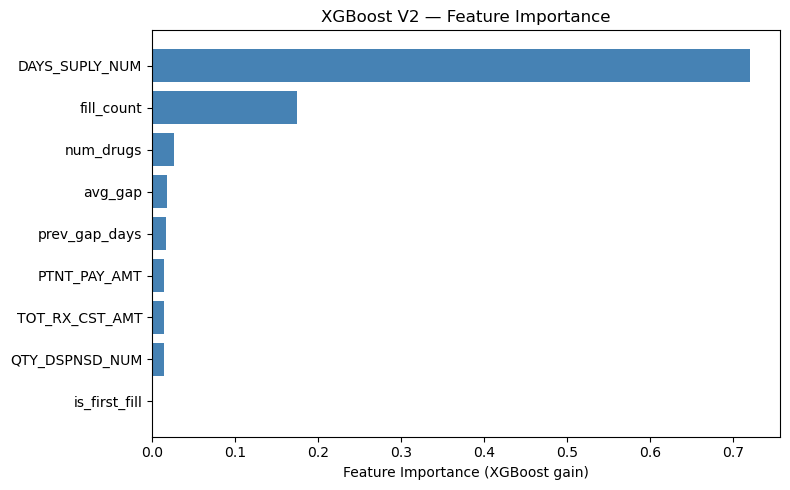

       feature  importance
DAYS_SUPLY_NUM    0.720628
    fill_count    0.174443
     num_drugs    0.026489
       avg_gap    0.017965
 prev_gap_days    0.017077
  PTNT_PAY_AMT    0.014639
TOT_RX_CST_AMT    0.014475
QTY_DSPNSD_NUM    0.014282
 is_first_fill    0.000000


In [94]:
import matplotlib.pyplot as plt

# Get feature importances from XGBoost V2
importance_df = pd.DataFrame({
    'feature': FEATURES_V2,
    'importance': xgb_model_V2.feature_importances_
}).sort_values('importance', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
ax.set_xlabel('Feature Importance (XGBoost gain)')
ax.set_title('XGBoost V2 — Feature Importance')
plt.tight_layout()
plt.show()

# Also print the values
print(importance_df.sort_values('importance', ascending=False).to_string(index=False))

In [92]:
# XGBoost V3 — drop is_first_fill
X_train_V3 = train[FEATURES_V3]
X_test_V3  = test[FEATURES_V3]

xgb_model_V3 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='aucpr',
    verbosity=0
)
xgb_model_V3.fit(X_train_V3, y_train)

y_pred_proba_xgb_V3 = xgb_model_V3.predict_proba(X_test_V3)[:, 1]
pr_auc_xgb_V3 = average_precision_score(y_test, y_pred_proba_xgb_V3)

print(f"PR-AUC (XGBoost V3 - 8 features, no is_first_fill): {pr_auc_xgb_V3:.4f}")
print(f"PR-AUC (XGBoost V2 - 9 features):                   0.8008")
print(f"PR-AUC (XGBoost V1 - 7 features):                   0.8003")
print(f"PR-AUC (Logistic Reg):                               0.7919")

PR-AUC (XGBoost V3 - 8 features, no is_first_fill): 0.8008
PR-AUC (XGBoost V2 - 9 features):                   0.8008
PR-AUC (XGBoost V1 - 7 features):                   0.8003
PR-AUC (Logistic Reg):                               0.7919


In [96]:
# Trying to break the 80% PR-AUC cealing by loading the 
# beneficiary data and engineering some patient-level features
bene = pd.read_csv('C:/Users/itzel\OneDrive\Documents\GitHub\MATH-UoL-Hackathon\Data\DE1_0_2010_Beneficiary_Summary_File_Sample_1.csv')

# Check what we have
print(bene.shape)
print(bene.dtypes)
print(bene.head(3))

(112754, 32)
DESYNPUF_ID                  object
BENE_BIRTH_DT                 int64
BENE_DEATH_DT               float64
BENE_SEX_IDENT_CD             int64
BENE_RACE_CD                  int64
BENE_ESRD_IND                object
SP_STATE_CODE                 int64
BENE_COUNTY_CD                int64
BENE_HI_CVRAGE_TOT_MONS       int64
BENE_SMI_CVRAGE_TOT_MONS      int64
BENE_HMO_CVRAGE_TOT_MONS      int64
PLAN_CVRG_MOS_NUM             int64
SP_ALZHDMTA                   int64
SP_CHF                        int64
SP_CHRNKIDN                   int64
SP_CNCR                       int64
SP_COPD                       int64
SP_DEPRESSN                   int64
SP_DIABETES                   int64
SP_ISCHMCHT                   int64
SP_OSTEOPRS                   int64
SP_RA_OA                      int64
SP_STRKETIA                   int64
MEDREIMB_IP                 float64
BENRES_IP                   float64
PPPYMT_IP                   float64
MEDREIMB_OP                 float64
BENRES_OP      

In [97]:
# --- Engineer patient-level features from Beneficiary Summary ---

# 1. Derive age from birth date (using 2010 as reference year)
bene['age'] = 2010 - (bene['BENE_BIRTH_DT'] // 10000)

# 2. SP_ columns: 1 = has condition, 2 = no → recode to binary
sp_cols = ['SP_ALZHDMTA','SP_CHF','SP_CHRNKIDN','SP_CNCR','SP_COPD',
           'SP_DEPRESSN','SP_DIABETES','SP_ISCHMCHT','SP_OSTEOPRS',
           'SP_RA_OA','SP_STRKETIA']

for col in sp_cols:
    bene[col] = (bene[col] == 1).astype(int)

# 3. Total number of chronic conditions
bene['num_conditions'] = bene[sp_cols].sum(axis=1)

# 4. ESRD flag: 'Y' → 1, '0' → 0
bene['esrd_flag'] = (bene['BENE_ESRD_IND'] == 'Y').astype(int)

# Select only the columns we need for merging
bene_features = bene[['DESYNPUF_ID', 'age', 'BENE_SEX_IDENT_CD', 
                       'BENE_RACE_CD', 'num_conditions', 'esrd_flag',
                       'BENE_HI_CVRAGE_TOT_MONS'] + sp_cols]

print(bene_features.shape)
print(bene_features[['age','num_conditions','esrd_flag']].describe())

(112754, 18)
                 age  num_conditions      esrd_flag
count  112754.000000   112754.000000  112754.000000
mean       73.614142        1.800770       0.071102
std        12.561557        1.988318       0.256996
min        27.000000        0.000000       0.000000
25%        68.000000        0.000000       0.000000
50%        74.000000        1.000000       0.000000
75%        82.000000        3.000000       0.000000
max       101.000000       11.000000       1.000000


In [98]:
# Merge bene_features onto labelled rows
df_v4 = df_labelled.merge(bene_features, on='DESYNPUF_ID', how='left')

print(f"Rows after merge: {len(df_v4)}")
print(f"NaNs introduced:\n{df_v4[bene_features.columns].isnull().sum()}")

# Features for V4
feature_cols_v4 = [
    'DAYS_SUPLY_NUM', 'QTY_DSPNSD_NUM', 'PTNT_PAY_AMT', 'TOT_RX_CST_AMT',
    'fill_count', 'prev_gap_days', 'avg_gap', 'num_drugs',
    'age', 'BENE_SEX_IDENT_CD', 'BENE_RACE_CD', 'num_conditions',
    'esrd_flag', 'BENE_HI_CVRAGE_TOT_MONS'
] + sp_cols

X = df_v4[feature_cols_v4]
y = df_v4['is_late']

split = int(len(df_v4) * 0.9)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_v4 = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                          scale_pos_weight=scale_pos_weight,
                          eval_metric='aucpr', random_state=42)
model_v4.fit(X_train, y_train)

y_prob_v4 = model_v4.predict_proba(X_test)[:, 1]
prauc_v4 = average_precision_score(y_test, y_prob_v4)

print(f"\nPR-AUC (XGBoost V4 - +demographics & conditions): {prauc_v4:.4f}")
print(f"PR-AUC (XGBoost V3 - 8 features):                  0.8008  ← previous best")
print("\n", classification_report(y_test, (y_prob_v4 >= 0.5).astype(int)))

Rows after merge: 1142880
NaNs introduced:
DESYNPUF_ID                   0
age                        7142
BENE_SEX_IDENT_CD          7142
BENE_RACE_CD               7142
num_conditions             7142
esrd_flag                  7142
BENE_HI_CVRAGE_TOT_MONS    7142
SP_ALZHDMTA                7142
SP_CHF                     7142
SP_CHRNKIDN                7142
SP_CNCR                    7142
SP_COPD                    7142
SP_DEPRESSN                7142
SP_DIABETES                7142
SP_ISCHMCHT                7142
SP_OSTEOPRS                7142
SP_RA_OA                   7142
SP_STRKETIA                7142
dtype: int64

PR-AUC (XGBoost V4 - +demographics & conditions): 0.9272
PR-AUC (XGBoost V3 - 8 features):                  0.8008  ← previous best

               precision    recall  f1-score   support

           0       0.21      0.48      0.29     13518
           1       0.91      0.75      0.83    100770

    accuracy                           0.72    114288
   macro avg   

In [100]:
from sklearn.metrics import precision_recall_fscore_support

# Threshold sweep
thresholds = np.linspace(0.1, 0.9, 17)  # 0.10, 0.15, ..., 0.90

rows = []
for thr in thresholds:
    y_pred_thr = (y_prob_v4 >= thr).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred_thr, average='binary', pos_label=1
    )
    flagged_pct = y_pred_thr.mean()  # fraction predicted late
    rows.append([thr, precision, recall, f1, flagged_pct])

thr_df = pd.DataFrame(rows, columns=['threshold','precision','recall','f1','flagged_pct'])

print(thr_df)

    threshold  precision    recall        f1  flagged_pct
0        0.10   0.882530  0.999097  0.937203     0.998180
1        0.15   0.883892  0.996894  0.936998     0.994444
2        0.20   0.885977  0.992220  0.936093     0.987453
3        0.25   0.888984  0.980441  0.932475     0.972429
4        0.30   0.896064  0.940756  0.917866     0.925696
5        0.35   0.903484  0.894671  0.899056     0.873119
6        0.40   0.907161  0.862906  0.884480     0.838706
7        0.45   0.910709  0.819123  0.862491     0.793049
8        0.50   0.914793  0.752397  0.825686     0.725194
9        0.55   0.920132  0.574486  0.707342     0.550504
10       0.60   0.940640  0.210876  0.344517     0.197667
11       0.65   0.955349  0.139923  0.244095     0.129139
12       0.70   0.960346  0.102382  0.185037     0.093999
13       0.75   0.965472  0.051057  0.096985     0.046628
14       0.80   0.976675  0.022854  0.044663     0.020632
15       0.85   0.980071  0.013665  0.026954     0.012294
16       0.90 

In [103]:
# 1) Check basic shapes
print("Number of features in training:", len(feature_cols_v4))
print("Feature importance vector length:", len(model_v4.feature_importances_))

# 2) Build feature-importance table
feat_imp_v4 = pd.DataFrame({
    'feature': feature_cols_v4,
    'importance': model_v4.feature_importances_
}).sort_values('importance', ascending=False)

print(feat_imp_v4.head(20))

Number of features in training: 25
Feature importance vector length: 25
                    feature  importance
0            DAYS_SUPLY_NUM    0.625961
4                fill_count    0.155780
5             prev_gap_days    0.022727
6                   avg_gap    0.018581
7                 num_drugs    0.013446
8                       age    0.010318
20              SP_DIABETES    0.009659
12                esrd_flag    0.009110
18                  SP_COPD    0.008972
13  BENE_HI_CVRAGE_TOT_MONS    0.008769
11           num_conditions    0.008626
14              SP_ALZHDMTA    0.008359
10             BENE_RACE_CD    0.008227
2              PTNT_PAY_AMT    0.008163
1            QTY_DSPNSD_NUM    0.007857
3            TOT_RX_CST_AMT    0.007826
22              SP_OSTEOPRS    0.007810
15                   SP_CHF    0.007798
19              SP_DEPRESSN    0.007783
23                 SP_RA_OA    0.007716


In [104]:
# Define feature groups
refill_feats = [
    'DAYS_SUPLY_NUM', 'QTY_DSPNSD_NUM', 'PTNT_PAY_AMT', 'TOT_RX_CST_AMT',
    'fill_count', 'prev_gap_days', 'avg_gap', 'num_drugs'
]

demo_feats = [
    'age', 'BENE_SEX_IDENT_CD', 'BENE_RACE_CD', 'BENE_HI_CVRAGE_TOT_MONS'
]

cond_feats = [
    'num_conditions', 'esrd_flag',
    'SP_ALZHDMTA','SP_CHF','SP_CHRNKIDN','SP_CNCR','SP_COPD',
    'SP_DEPRESSN','SP_DIABETES','SP_ISCHMCHT','SP_OSTEOPRS',
    'SP_RA_OA','SP_STRKETIA'
]

# Start from your existing feat_imp_v4
feat_imp_v4['group'] = 'other'
feat_imp_v4.loc[feat_imp_v4['feature'].isin(refill_feats), 'group'] = 'refill_behavior'
feat_imp_v4.loc[feat_imp_v4['feature'].isin(demo_feats), 'group'] = 'demographics'
feat_imp_v4.loc[feat_imp_v4['feature'].isin(cond_feats), 'group'] = 'chronic_conditions'

# Sorted table by importance
feat_imp_sorted = feat_imp_v4.sort_values('importance', ascending=False)
print(feat_imp_sorted)

# Optional: group-level summary (nice for a slide)
group_summary = feat_imp_sorted.groupby('group')['importance'].sum().reset_index()
print("\nGroup-level importance:")
print(group_summary)

                    feature  importance               group
0            DAYS_SUPLY_NUM    0.625961     refill_behavior
4                fill_count    0.155780     refill_behavior
5             prev_gap_days    0.022727     refill_behavior
6                   avg_gap    0.018581     refill_behavior
7                 num_drugs    0.013446     refill_behavior
8                       age    0.010318        demographics
20              SP_DIABETES    0.009659  chronic_conditions
12                esrd_flag    0.009110  chronic_conditions
18                  SP_COPD    0.008972  chronic_conditions
13  BENE_HI_CVRAGE_TOT_MONS    0.008769        demographics
11           num_conditions    0.008626  chronic_conditions
14              SP_ALZHDMTA    0.008359  chronic_conditions
10             BENE_RACE_CD    0.008227        demographics
2              PTNT_PAY_AMT    0.008163     refill_behavior
1            QTY_DSPNSD_NUM    0.007857     refill_behavior
3            TOT_RX_CST_AMT    0.007826 

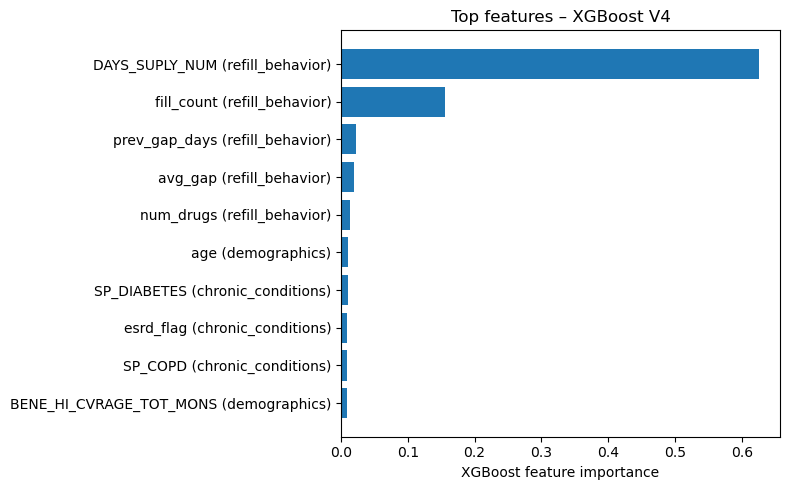

In [109]:
import matplotlib.pyplot as plt

# Take top N features
top_n = 10
top_feats = feat_imp_sorted.head(top_n)

plt.figure(figsize=(8, 5))
# Reverse order so the most important is at the top
y_pos = range(len(top_feats))[::-1]
plt.barh(
    [f"{f} ({g})" for f, g in zip(top_feats['feature'], top_feats['group'])][::-1],
    top_feats['importance'][::-1]
)
plt.xlabel('XGBoost feature importance')
plt.title('Top features – XGBoost V4')
plt.tight_layout()
plt.show()

In [106]:
# Pick out the two operating points
summary_thr = thr_df[thr_df['threshold'].isin([0.35, 0.50])].copy()
summary_thr['threshold'] = summary_thr['threshold'].astype(str)

print(summary_thr)

  threshold  precision    recall        f1  flagged_pct
5      0.35   0.903484  0.894671  0.899056     0.873119
8       0.5   0.914793  0.752397  0.825686     0.725194


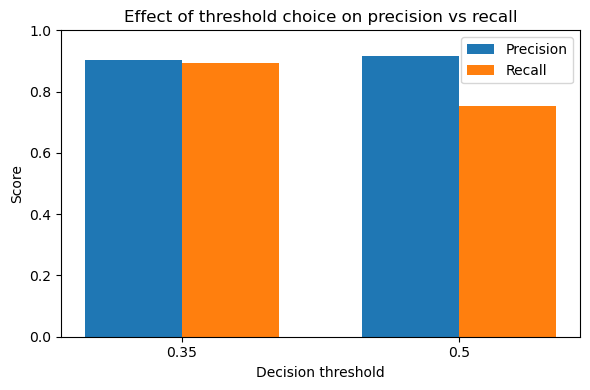

In [107]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['precision', 'recall']
x = np.arange(len(summary_thr))  # positions for thresholds
width = 0.35

plt.figure(figsize=(6, 4))

plt.bar(x - width/2, summary_thr['precision'], width, label='Precision')
plt.bar(x + width/2, summary_thr['recall'],    width, label='Recall')

plt.xticks(x, summary_thr['threshold'])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.xlabel('Decision threshold')
plt.title('Effect of threshold choice on precision vs recall')
plt.legend()
plt.tight_layout()
plt.show()

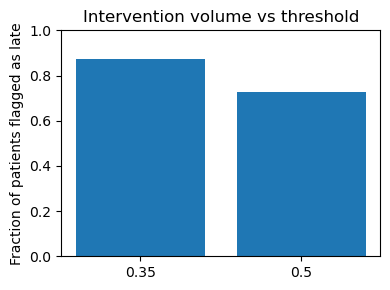

In [108]:
plt.figure(figsize=(4, 3))
plt.bar(summary_thr['threshold'], summary_thr['flagged_pct'])
plt.ylim(0, 1)
plt.ylabel('Fraction of patients flagged as late')
plt.title('Intervention volume vs threshold')
plt.tight_layout()
plt.show()